Sentiment Analysis


In [11]:
# Enable the built-in IPython auto-reloader extension
%load_ext autoreload

# Set it to reload all modules before executing any code cell
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import sys
import os
sys.path.append(os.path.abspath('../'))
from src.sentiment_analysis import (
    modular_nlp_pipeline, 
    sia, 
    get_vader_label, 
    classify_hf_local
)

ImportError: cannot import name 'modular_nlp_pipeline' from 'src.sentiment_analysis' (c:\Users\Hermela\Desktop\10academy\Week2\src\sentiment_analysis.py)

In [2]:
import nltk
import ssl

# Bypass SSL certificate verification for standard library HTTPS requests
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Execute NLTK resource downloads with standard console output
print("Initiating NLTK resource downloads...")
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
print("Download sequence complete.")

Initiating NLTK resource downloads...
Download sequence complete.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hermela\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hermela\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Hermela\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
import os
import sys
import pandas as pd
import nltk

# 1. Set project root for imports and data loading
if os.getcwd().endswith('notebook'):
    os.chdir('..')
sys.path.append(os.path.abspath('.'))

# 2. Explicitly point NLTK to the downloaded data folder
nltk_path = r"C:\Users\Hermela\AppData\Roaming\nltk_data"
nltk.data.path.append(nltk_path)

# 3. Download the missing 'punkt_tab' package directly to that folder
nltk.download('punkt_tab', download_dir=nltk_path, quiet=True)

# 4. Import custom NLP pipeline modules
from src.sentiment_analysis import preprocess_for_nlp, classify_review_sentiment

# 5. Load cleaned data from Task 1
df = pd.read_csv('data/processed/all_banks_combined_clean.csv')

# 6. Apply NLP Preprocessing 
print("Running tokenization and lemmatization...")
df['nlp_ready_text'] = df['review'].apply(preprocess_for_nlp)

# 7. Drop empty records resulting from text cleaning
df = df[df['nlp_ready_text'].str.strip().str.len() > 0].copy()

print(f"Dataset size after NLP processing: {len(df)}")

Running tokenization and lemmatization...
Dataset size after NLP processing: 1664


Rating & Data Quality Distribution

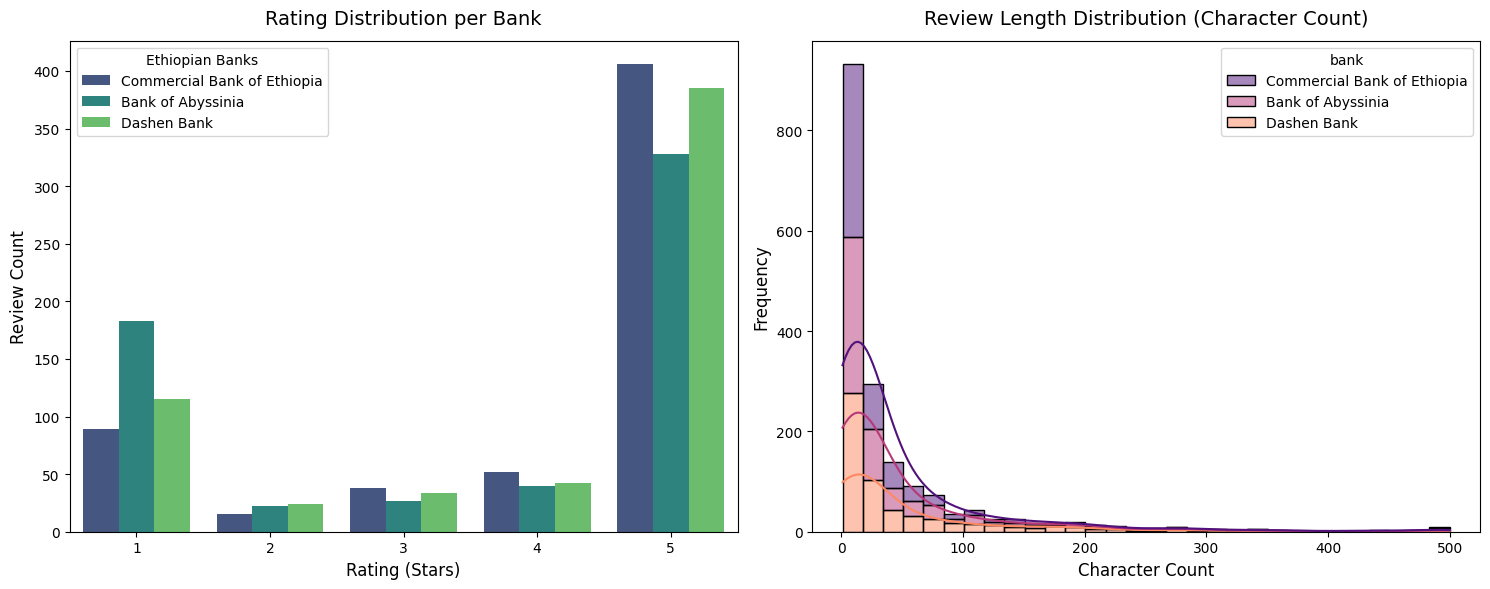

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Or just import seaborn as sns


# 1. Load the master combined dataset generated in Task 1
df_clean = pd.read_csv('data/processed/all_banks_combined_clean.csv')

# 2. Setup the visualization canvas (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Rating Distribution per Bank ---
# Using 'bank' as the hue to compare CBE, BOA, and Dashen side-by-side [cite: 17, 126]
sns.countplot(data=df_clean, x='rating', hue='bank', palette='viridis', ax=ax[0])
ax[0].set_title('Rating Distribution per Bank', fontsize=14, pad=12)
ax[0].set_xlabel('Rating (Stars)', fontsize=12)
ax[0].set_ylabel('Review Count', fontsize=12)
ax[0].legend(title='Ethiopian Banks')

# --- Plot 2: Review Length Distribution ---
# Calculate the character length of each clean review
df_clean['review_len'] = df_clean['review'].astype(str).str.len()

# Using hue='bank' here as well allows you to see if users write longer reviews for specific apps
sns.histplot(data=df_clean, x='review_len', hue='bank', bins=30, kde=True, palette='magma', multiple='stack', ax=ax[1])
ax[1].set_title('Review Length Distribution (Character Count)', fontsize=14, pad=12)
ax[1].set_xlabel('Character Count', fontsize=12)
ax[1].set_ylabel('Frequency', fontsize=12)

# Clean up layout and display
plt.tight_layout()
plt.show()

Thematic Analysis

a) Theme Definition

In [5]:
# b) Extract significant keywords and n-grams using TF-IDF and CountVectorizer
from src.thematic_analysis import extract_themes_per_bank, plot_themes_per_bank

print("Extracting Unigrams and Bigrams via modular pipeline...")

# 1. Safety check to ensure NLP column exists
if 'nlp_ready_text' not in df.columns:
    from src.sentiment_analysis import preprocess_for_nlp
    df['nlp_ready_text'] = df['review'].apply(preprocess_for_nlp)
    df = df[df['nlp_ready_text'].str.strip().str.len() > 0].copy()

# 2. Extract themes specific to each company
print("Extracting comparative themes per bank...")
bank_themes_df = extract_themes_per_bank(df, text_column='nlp_ready_text', bank_column='bank', top_n=8)

# 3. Display the results in a clean table
display(bank_themes_df)

Extracting Unigrams and Bigrams via modular pipeline...
Extracting comparative themes per bank...


,Top Keywords,Top Phrases
Commercial Bank of Ethiopia,"good, app, nice, best, cbe, like, application,...","nice app, good app, easy use, best app, mobile..."
Bank of Abyssinia,"good, app, best, nice, boa, bank, work, working","mobile banking, banking app, good app, best ap..."
Dashen Bank,"good, app, nice, best, bank, dashen, great, super","dashen bank, super app, easy use, best app, ni..."


In [6]:
# Enable the built-in IPython auto-reloader extension
%load_ext autoreload

# Set it to reload all modules before executing any code cell
%autoreload 2

Mapping clean review texts to functional business themes...
Generating localized thematic distribution profiles...


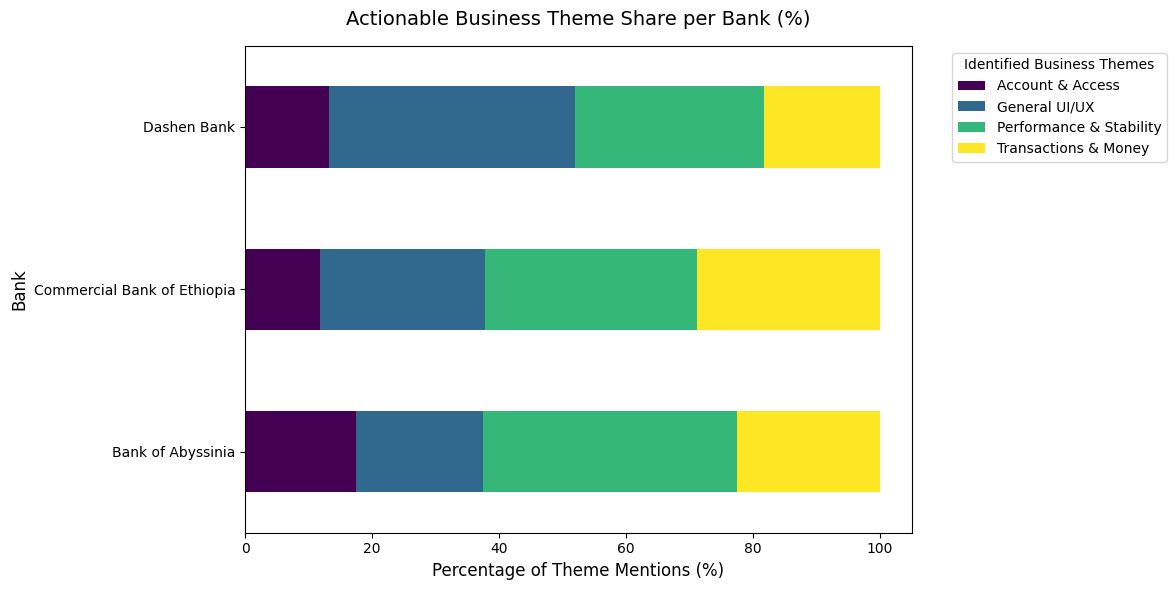

In [8]:
import os
import sys
import pandas as pd

# Set project root for imports and data loading
if os.getcwd().endswith('notebook'):
    os.chdir('..')
sys.path.append(os.path.abspath('.'))

# Force clear Jupyter's active internal module cache for your file
if 'src.thematic_analysis' in sys.modules:
    del sys.modules['src.thematic_analysis']

# Import the updated definitions fresh from disk
from src.thematic_analysis import assign_themes, plot_themes_per_bank

# 1. Map text rows to overarching business categories if not already done
if 'business_themes' not in df.columns:
    print("Mapping clean review texts to functional business themes...")
    df['business_themes'] = df['nlp_ready_text'].apply(assign_themes)

# 2. Call the modular visualization pipeline
print("Generating localized thematic distribution profiles...")
plot_themes_per_bank(df, theme_column='business_themes', bank_column='bank')